Text Sentence -> Tokens

In [1]:
sentence = "I love Machine Learning."
tokens = sentence.split()
print(tokens)

['I', 'love', 'Machine', 'Learning.']


Tokens -> Numbers

In [3]:
word_to_index = {
    "I" : 1,
    "love": 2,
    "Machine": 3,
    "Learning.": 4
}

Convert each token into its matching index number

In [5]:
indexed_sequence = [word_to_index[word] for word in tokens]
print('Tokens: ', tokens)
print('Indexed Sequences: ', indexed_sequence)

Tokens:  ['I', 'love', 'Machine', 'Learning.']
Indexed Sequences:  [1, 2, 3, 4]


In [6]:
encoder_hidden_states = []

import numpy as np
hidden_state = np.random.rand(4)
print(hidden_state)

[0.95255662 0.61089638 0.22264918 0.53162327]


In [7]:
encoder_hidden_states.append(hidden_state)
context_vector = encoder_hidden_states[-1]
print(context_vector)

[0.95255662 0.61089638 0.22264918 0.53162327]


Attention Scores

In [8]:
# Step 1: Create input words
input_words = ["The", "cat", "sat", "on", "the", "mat"]

# Step 2: Create attention scores for each input word
attention_scores = [0.1, 0.5, 0.2, 0.05, 0.05, 0.1]

# Step 3: Print each word with its attention score
for word, score in zip(input_words, attention_scores):
    print(word, ":", score)

The : 0.1
cat : 0.5
sat : 0.2
on : 0.05
the : 0.05
mat : 0.1


Create Attention Scores

In [9]:
import tensorflow as tf

hindi_words = ["मुझे", "क्रिकेट", "पसंद", "है"]

scores = tf.constant([1.0, 5.0, 0.5, 0.2])

print(scores.numpy())

[1.  5.  0.5 0.2]


Convert scores to attention weights

In [10]:
attention_weights = tf.nn.softmax(scores)
print(attention_weights)

tf.Tensor([0.017651   0.963712   0.01070587 0.0079311 ], shape=(4,), dtype=float32)


While generating "cricket", the model is looking 96% at "क्रिकेट".

Visualize

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2333 (\N{DEVANAGARI LETTER JHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/

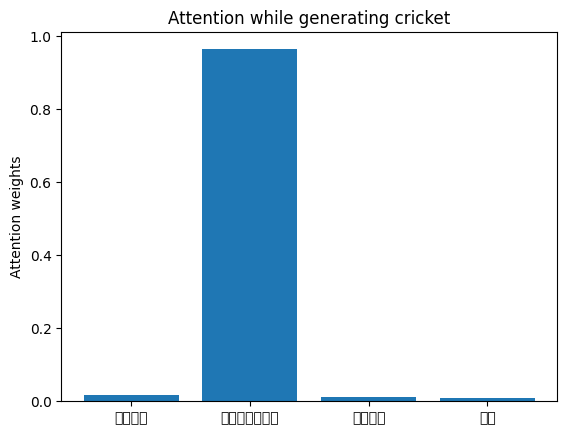

In [11]:
import matplotlib.pyplot as plt

plt.bar(hindi_words, attention_weights.numpy())
plt.title("Attention while generating cricket")
plt.ylabel("Attention weights")
plt.show()

Context Vector Calculation

In [12]:
hidden_state = tf.constant([
    [1, 2], #h1
    [8, 9], #h2
    [2, 1], #h3
    [1, 1]  #h4
], dtype = tf.float32)

print(hidden_state)

tf.Tensor(
[[1. 2.]
 [8. 9.]
 [2. 1.]
 [1. 1.]], shape=(4, 2), dtype=float32)


In [13]:
context_vector = tf.reduce_sum(tf.expand_dims(attention_weights, axis=1) * hidden_state, axis=0)
print(context_vector.numpy())

[7.75669  8.727346]


Install libraries

In [14]:
!pip install transformers sentencepiece torch

Load Pretrained Model

In [15]:
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM

model_name = "Helsinki-NLP/opus-mt-hi-en"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
)

config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.06M [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  304MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Hindi to English Translation

In [16]:
sentence = "मुझे क्रिकेट पसंद है"

inputs = tokenizer(
    sentence,
    return_tensors="pt"
)

translated_ids = model.generate(
    **inputs,
    max_length=20
)

translation = tokenizer.decode(
    translated_ids[0],
    skip_special_tokens=True
)

print("Translation:", translation)

Translation: I like cricket


In [17]:
encoder = model.get_encoder()
encoder_output = encoder(
    input_ids = inputs["input_ids"]
)

print(encoder_output.last_hidden_state.shape)

torch.Size([1, 5, 512])


1 => Batch Size, 5 => Number of tokens in the hindi sentence, 512 => Hidden Representation Size

Every hindi token gets converted into 512 dimensional representation

In [27]:
tokens = tokenizer.convert_ids_to_tokens(
    inputs['input_ids'][0]
)

print(tokens)

['▁मुझे', '▁क्रिकेट', '▁पसंद', '▁है', '</s>']


Why attention weights are useful?

It is useful because they show which input words are important during output generation task. For each output word, the model assign weights to input words.

In seq2seq with attention, the context vector is dynamic. Dynamic simply means that it can change at every decoder step.

Working Of Translation Models from scratch

In [28]:
data = [
    ("i am learning nlp", "je apprends le nlp"),
    ("i love machine learning", "j aime apprentissage automatique"),
    ("this is a good model", "ceci est un bon modele")
]

In [29]:
input_sentence = data[1][0]
output_sentence = data[1][1]

print("Input Sentence:", input_sentence)
print("Output Sentence:", output_sentence)

Input Sentence: i love machine learning
Output Sentence: j aime apprentissage automatique


In [30]:
input_tokens = input_sentence.split()
output_tokens = output_sentence.split()

print("\nInput Tokens:", input_tokens)
print("Output Tokens:", output_tokens)


Input Tokens: ['i', 'love', 'machine', 'learning']
Output Tokens: ['j', 'aime', 'apprentissage', 'automatique']


In [31]:
input_word_to_index = {}

for word in input_tokens:
    if word not in input_word_to_index:
        input_word_to_index[word] = len(input_word_to_index) + 1

output_word_to_index = {}

for word in output_tokens:
    if word not in output_word_to_index:
        output_word_to_index[word] = len(output_word_to_index) + 1

print("\nInput Word to Index:", input_word_to_index)
print("Output Word to Index:", output_word_to_index)


Input Word to Index: {'i': 1, 'love': 2, 'machine': 3, 'learning': 4}
Output Word to Index: {'j': 1, 'aime': 2, 'apprentissage': 3, 'automatique': 4}


In [32]:
input_sequence = [input_word_to_index[word] for word in input_tokens]
output_sequence = [output_word_to_index[word] for word in output_tokens]

print("\nInput Sequence:", input_sequence)
print("Output Sequence:", output_sequence)


Input Sequence: [1, 2, 3, 4]
Output Sequence: [1, 2, 3, 4]


In [33]:
encoder_hidden_states = np.array([
    [0.1, 0.2, 0.3],   # hidden state for "i"
    [0.3, 0.8, 0.4],   # hidden state for "love"
    [0.7, 0.2, 0.9],   # hidden state for "machine"
    [0.6, 0.3, 0.8]    # hidden state for "learning"
])

print("\nEncoder Hidden States:")
for word, state in zip(input_tokens, encoder_hidden_states):
    print(word, ":", state)


Encoder Hidden States:
i : [0.1 0.2 0.3]
love : [0.3 0.8 0.4]
machine : [0.7 0.2 0.9]
learning : [0.6 0.3 0.8]


In [34]:
decoder_hidden_states = np.array([
    [0.3, 0.7, 0.4],   # decoder state for "j"
    [0.3, 0.8, 0.4],   # decoder state for "aime"
    [0.7, 0.2, 0.9],   # decoder state for "apprentissage"
    [0.6, 0.3, 0.8]    # decoder state for "automatique"
])

print("\nDecoder Hidden States:")
for word, state in zip(output_tokens, decoder_hidden_states):
    print(word, ":", state)


Decoder Hidden States:
j : [0.3 0.7 0.4]
aime : [0.3 0.8 0.4]
apprentissage : [0.7 0.2 0.9]
automatique : [0.6 0.3 0.8]


In [35]:
# Step 8: Define softmax function
def softmax(scores):
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores)

In [36]:
# Calculate attention scores and attention weights
attention_matrix = []

for decoder_state in decoder_hidden_states:
    scores = np.dot(encoder_hidden_states, decoder_state)
    attention_weights = softmax(scores)
    attention_matrix.append(attention_weights)

attention_matrix = np.array(attention_matrix)

print("\nAttention Matrix:")
print(attention_matrix)


Attention Matrix:
[[0.17464349 0.29375517 0.26580067 0.26580067]
 [0.17107886 0.30555342 0.26037545 0.26299227]
 [0.13696259 0.19435917 0.35770471 0.31097354]
 [0.14590591 0.21335596 0.33797162 0.30276652]]


In [37]:
context_vectors = []

for attention_weights in attention_matrix:
    context_vector = np.sum(
        encoder_hidden_states * attention_weights.reshape(-1, 1),
        axis=0
    )
    context_vectors.append(context_vector)

context_vectors = np.array(context_vectors)

print("\nContext Vectors:")
for word, context in zip(output_tokens, context_vectors):
    print(word, ":", context)


Context Vectors:
j : [0.45113177 0.40283317 0.62175626]
aime : [0.44883209 0.40963128 0.61827675]
apprentissage : [0.50898143 0.34771285 0.68954551]
automatique : [0.49683742 0.35829023 0.67550183]


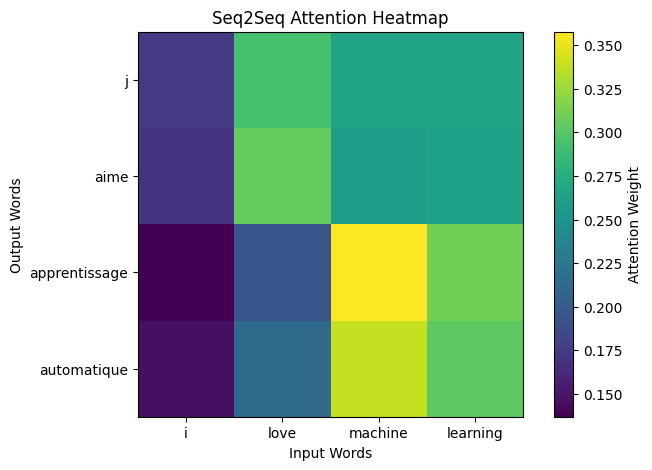

In [38]:
plt.figure(figsize=(8, 5))

plt.imshow(attention_matrix)

plt.xticks(range(len(input_tokens)), input_tokens)
plt.yticks(range(len(output_tokens)), output_tokens)

plt.xlabel("Input Words")
plt.ylabel("Output Words")
plt.title("Seq2Seq Attention Heatmap")

plt.colorbar(label="Attention Weight")

plt.show()